In [59]:
import polars as pl
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.utils import compute_class_weight, class_weight
from sklearn.metrics import classification_report, precision_recall_curve, auc, average_precision_score
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
path = "/home/jovyan/work/"

I0000 00:00:1786889948.694148   30403 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786889949.129134   30403 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786889950.995298   30403 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786889950.997093   30403 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
features_df = (
    pl.scan_parquet(f"{path}data/gold/Polars/feature_complete_fraud_data.parquet")
    .select(pl.all().exclude("merchant_latitude", "merchant_longitude"))
)

features_df.show(5)

client_id,card_id,date,id,target,agemonth_at_event,days_acct_open,days_expires,retirement_years,No_Errors,Bad_Card_Number,Bad_CVV,Bad_Expiration,Bad_PIN,Bad_Zipcode,Insufficient_Balance,Technical_Glitch,Visa,Discover,Amex,Mastercard,Debit_Prepaid,Credit,Debit,Online_Transaction,Chip_Transaction,Swipe_Transaction,Male,Log2_risk_factor,amount,credit_limit,yearly_income,total_debt,sum_amount_24h,mean_log_amount_7d,stddev_log_amount_7d,sum_amount_7d,…,ic_upper_speed_99,is_tdiffm_in_IC90,is_tdiffm_in_IC95,is_tdiffm_in_IC99,hour_of_day,theta,sin_theta,cos_theta,N_7d,day_of_week,weekend,mu_vM_7d,sigma_vM_7d,ic_lower_vm_90_7d,ic_upper_vm_90_7d,ic_lower_vm_95_7d,ic_upper_vm_95_7d,ic_lower_vm_99_7d,ic_upper_vm_99_7d,is_time_in_IC_90,is_time_in_IC_95,is_time_in_IC_99,log_time_diff_m,mean_time_diff_m,stddev_time_diff_m,ic_lower_tdiffm_90,ic_upper_tdiffm_90,ic_lower_tdiffm_95,ic_upper_tdiffm_95,ic_lower_tdiffm_99,ic_upper_tdiffm_99,is_tdiffm_in_IC90_right,is_tdiffm_in_IC95_right,is_tdiffm_in_IC99_right,aceleration_ratio_24h_vs_7d_is_inf,ratio_24_credit_limit_is_inf,ratio_24_total_debt_is_inf
str,str,datetime[μs],str,bool,i64,i64,i64,i64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,bool,bool,bool,f64,f64,f64,f64,u32,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,bool,bool,bool
"""0""","""1271""",2013-07-19 13:23:00.001906,"""13047138""",false,328,899,2812,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,0.5,42.52,31490.0,59613.0,36199.0,52.38,3.660233,0.861347,562.84,…,0.0,true,true,true,13.383333,-2.779437,-0.354291,-0.935135,14,5,true,-1.663538,1.198727,-2.230898,-1.096179,-2.355663,-0.971414,-2.628591,-0.698486,false,false,false,7.248504,5.526262,1.964124,4.596639,6.455886,4.392211,6.660314,3.945016,7.107509,false,false,false,false,false,false
"""0""","""1271""",2013-07-19 20:35:00.001908,"""13048785""",false,328,899,2812,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,-0.18,37.51,31490.0,59613.0,36199.0,52.79,3.667118,0.831563,605.25,…,0.004867,true,true,true,20.583333,-0.894481,-0.779884,0.625923,15,5,true,-1.777568,1.205201,-2.325655,-1.22948,-2.444986,-1.110149,-2.703907,-0.851229,false,false,true,2.833213,5.643853,1.944779,4.759429,6.528277,4.566871,6.720836,4.149062,7.138644,false,false,false,false,false,false
"""0""","""1271""",2013-07-20 13:18:00.001909,"""13051758""",false,328,900,2811,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,2.45,44.17,31490.0,59613.0,36199.0,90.3,3.641438,0.859551,551.63,…,0.0,true,true,true,13.3,-2.801253,-0.333807,-0.942641,14,6,true,-1.651931,1.195052,-2.217551,-1.08631,-2.341933,-0.961928,-2.614025,-0.689837,false,false,false,6.911747,5.48505,2.067322,4.506582,6.463517,4.291413,6.678686,3.820722,7.149377,false,false,true,false,false,false
"""0""","""1271""",2013-07-23 06:42:00.001911,"""13063377""",false,328,903,2808,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,-3.73,14.5,31490.0,59613.0,36199.0,47.47,3.814873,0.60868,434.15,…,0.0,true,true,true,6.7,1.754056,0.983255,-0.182236,11,2,false,-2.445773,1.100984,-3.047436,-1.84411,3.097761,-1.706122,2.785344,-1.393704,false,false,false,6.957497,5.535058,2.399648,4.223704,6.846412,3.922953,7.147164,3.242022,7.828094,false,true,true,false,false,false
"""0""","""1271""",2013-07-23 14:15:00.001912,"""13065451""",false,328,903,2808,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,true,false,false,true,-0.81,16.73,31490.0,59613.0,36199.0,14.5,3.70915,0.687576,400.06,…,0.0,true,true,true,14.25,-2.552544,-0.55557,-0.83147,11,2,false,-2.56345,1.320764,2.997968,-1.841682,2.832434,-1.676148,2.457651,-1.301365,true,true,

In [3]:
df = features_df.collect()

In [4]:
proportions = df.group_by("target").agg([
    pl.len().alias("cantidad"),
    (pl.len() / len(df) * 100).alias("porcentaje")
])

print(proportions)

shape: (2, 3)
┌────────┬──────────┬────────────┐
│ target ┆ cantidad ┆ porcentaje │
│ ---    ┆ ---      ┆ ---        │
│ bool   ┆ u32      ┆ f64        │
╞════════╪══════════╪════════════╡
│ false  ┆ 3112100  ┆ 99.706082  │
│ true   ┆ 9174     ┆ 0.293918   │
└────────┴──────────┴────────────┘


In [5]:
False_df = df.filter(~pl.col("target"))
False_train_df = False_df.sample(fraction=0.70, seed=777)
False_valtest_df = False_df.join(False_train_df, on="id", how="anti")
False_val_df = False_valtest_df.sample(fraction=0.50, seed=777)
False_test_df = False_valtest_df.join(False_val_df, on="id", how="anti")

True_df = df.filter(pl.col("target"))
True_train_df = True_df.sample(fraction=0.70, seed=777)
True_valtest_df = True_df.join(True_train_df, on="id", how="anti")
True_val_df = True_valtest_df.sample(fraction=0.50, seed=777)
True_test_df = True_valtest_df.join(True_val_df, on="id", how="anti")

## Tomaremos solo 100_000 transaciones legitimas para el entrenamiento ya que hay un alto desbalance entre
## las transacciones legítimas y las fraudulentas. Procederemos de forma proporcional para la validación

train_df = pl.concat([False_train_df, True_train_df]).sort(["client_id", "card_id", "date", "id"]) 
val_df = pl.concat([False_val_df, True_val_df]).sort(["client_id", "card_id", "date", "id"]) 
test_df = pl.concat([False_test_df, True_test_df]).sort(["client_id", "card_id", "date", "id"]) 

## Definimos los datos que usaremos para el entrenamiento, la validación y el testeo del modelo
scaler = StandardScaler()

X_train = scaler.fit_transform(
    train_df
    .drop("target", "client_id", "card_id", "date", "id")
    .cast(pl.Float32).to_numpy()
)
y_train = train_df["target"].cast(pl.Int8).to_numpy()

X_val = scaler.transform(
    val_df
    .drop("target", "client_id", "card_id", "date", "id")
    .cast(pl.Float32).to_numpy()
)
y_val = val_df["target"].cast(pl.Int8).to_numpy()

X_test = scaler.transform(
    test_df
    .drop("target", "client_id", "card_id", "date", "id")
    .cast(pl.Float32).to_numpy()
)
y_test = test_df["target"].cast(pl.Int8).to_numpy()

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

pos = int(len(train_df)*proportions[1, 2]/100)
neg = len(train_df) - pos
initial_bias = np.log([pos / neg])
output_bias = tf.keras.initializers.Constant(initial_bias)

In [57]:
def plot_PRAUC(precision, recall, pr_auc, ap, algorithm, name, colour):
    PRAUC_df = pl.DataFrame({"Recall": recall, "Precision": precision})
    
    light_PRAUC_df = PRAUC_df.gather_every(50)
    baseline = float(y_test.sum() / len(y_test))
    
    fig = px.line(
        light_PRAUC_df, 
        x='Recall', 
        y='Precision',
        title=f'<b>Precision-Recall Curve (PR-AUC): {name}</b>',
        labels={'Recall': '<b>Recall<b>', 'Precision': '<b>Precision<b>'}
    )
    
    fig.update_traces(
        line=dict(color=colour, width=4),
        name=f'{algorithm} (AUC = {pr_auc:.4f} | AP = {ap:.4f})',
        showlegend=True,
        hovertemplate='<b>Recall:</b> %{x:.4f}<br><b>Precision:</b> %{y:.4f}<extra></extra>'
    )
    
    fig.add_shape(
        type="line", x0=0, y0=baseline, x1=1, y1=baseline,
        line=dict(color="navy", width=2, dash="dash"),
    )
    
    fig.add_trace(px.scatter(x=[None], y=[None], labels={'x':'', 'y':''}).data[0])
    
    fig.data[-1].update(
        name=f'Random Classifier (Prop. = {baseline:.4f})', 
        showlegend=True, mode='lines',
        line=dict(color="navy", width=2, dash="dash")
    )
    
    fig.update_layout(
        width=700, height=500, title_x=0.5, autosize=False,
        xaxis=dict(range=[0.0, 1.0], gridcolor='rgba(0,0,0,0.1)'),
        yaxis=dict(range=[0.0, 1.05], gridcolor='rgba(0,0,0,0.1)'),
        plot_bgcolor='white',
        legend=dict(x=0.45, y=1.1, bgcolor='rgba(255, 255, 255, 0.8)')
    )
    
    return fig

def plot_monitoring(history, name):
    df_history = pd.DataFrame(history.history)
    df_history['Epoch'] = df_history.index + 1
    
    fig_auc = px.line(
        df_history, 
        x='Epoch', 
        y=['pr_auc', 'val_pr_auc'], 
        labels={'value': 'PR-AUC score', 'variable': 'Set'},
        title=f"Monitoring: {name}"
    )
    
    new_names_auc = {'pr_auc': 'Train', 'val_pr_auc': 'Validation'}
    fig_auc.for_each_trace(lambda t: t.update(name = new_names_auc[t.name]))
    
    fig_auc.update_traces(line=dict(width=2.5))
    fig_auc.update_layout(
        width=700, height=500, autosize=False,
        template='plotly_white', hovermode='x unified', title_x=0.5
    )
    
    return fig_auc

En esta sección entrenaremos el modelo con una red MLP y probaremos las opciones:  
- binary_crossentropy + class_weights  
- BinaryFocalCrossentropy

In [7]:
input_shape = (X_train.shape[1],)

def create_model():
    return tf.keras.Sequential([
        layers.Input(shape=input_shape),
    
        layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
    
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
    
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
    
        layers.Dense(1, activation="sigmoid",  bias_initializer=output_bias)
    ])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=10,
    restore_best_weights=True
)

def create_checkpoint(fpath):
    return tf.keras.callbacks.ModelCheckpoint(
        filepath=fpath,
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        verbose=1
)

In [8]:
model_mlp_1 = create_model()

model_mlp_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

checkpoint_1 = create_checkpoint(f"{path}mldl/DL_MLP_1.keras")

history_mlp_1 = model_mlp_1.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=2048,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, checkpoint_1],
    shuffle=True
)

E0000 00:00:1786794173.413854   32112 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
1066/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.7691 - pr_auc: 0.1309 - precision: 0.0385 - recall: 0.8323
Epoch 1: val_pr_auc improved from None to 0.49065, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_MLP_1.keras

Epoch 1: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_MLP_1.keras
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 64s 58ms/step - loss: 0.6024 - pr_auc: 0.1709 - precision: 0.0395 - recall: 0.8991 - val_loss: 0.4368 - val_pr_auc: 0.4907 - val_precision: 0.0586 - val_recall: 0.9310
Epoch 2/50
1066/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.4649 - pr_auc: 0.2552 - precision: 0.0430 - recall: 0.9280
Epoch 2: val_pr_auc did not improve from 0.49065
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 62s 58ms/step - loss: 0.4430 - pr_auc: 0.2680 - precision: 0.0433 - recall: 0.9254 - val_loss: 0.3581 - val_pr_auc: 0.4690 - val_precision: 0.0533 - val_recall: 0.9419
Epoch 3/50
1066/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.3547 - pr_auc:

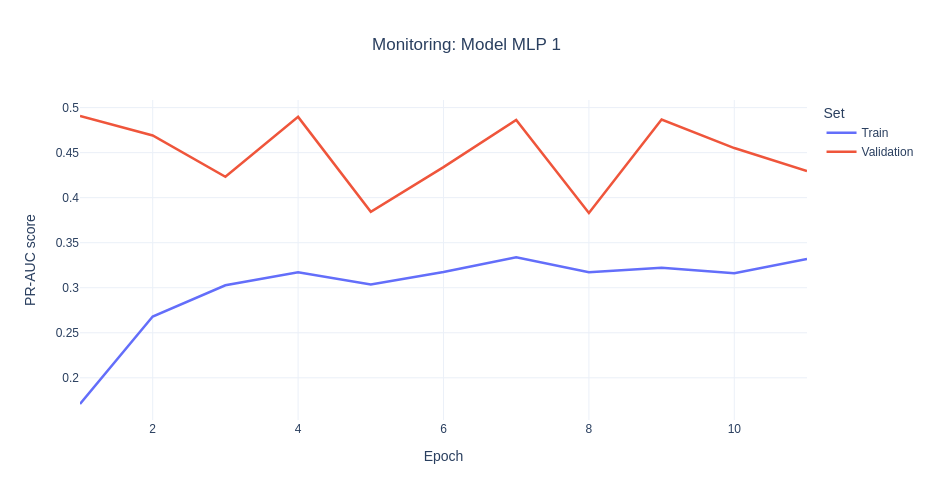

In [9]:
plot_monitoring(history_mlp_1, "Model MLP 1")

In [11]:
y_val_scores_mlp_1 = model_mlp_1.predict(X_val)
precisions_val_mlp_1, recalls_val_mlp_1, thresholds_val_mlp_1 = precision_recall_curve(y_val, y_val_scores_mlp_1)
calibrated_threshold_mlp_1 = thresholds_val_mlp_1[np.where(recalls_val_mlp_1 >= 0.80)[0][-1]]

test_probs_mlp_1 = (model_mlp_1.predict(X_test)).ravel()
final_test_preds_mlp_1 = test_probs_mlp_1 > calibrated_threshold_mlp_1
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_mlp_1))

precision_mlp_1, recall_mlp_1, thresholds_mlp_1 = precision_recall_curve(y_test, test_probs_mlp_1)
pr_auc_mlp_1 = auc(recall_mlp_1, precision_mlp_1)
ap_mlp_1 = average_precision_score(y_test, test_probs_mlp_1)
print(f"PR-AUC Score: {pr_auc_mlp_1:.4f}")
print(f"Average Precision (AP) Score: {ap_mlp_1:.4f}")

14631/14631 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
14631/14631 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    466815
           1       0.16      0.80      0.27      1377

    accuracy                           0.99    468192
   macro avg       0.58      0.90      0.63    468192
weighted avg       1.00      0.99      0.99    468192

PR-AUC Score: 0.5017
Average Precision (AP) Score: 0.5016


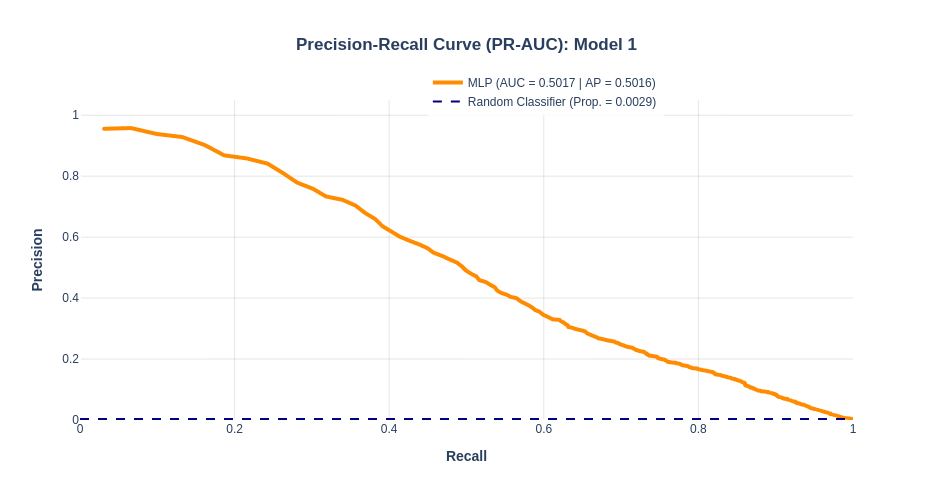

In [12]:
plot_PRAUC(precision_mlp_1, recall_mlp_1, pr_auc_mlp_1, ap_mlp_1, "MLP", "Model 1", "darkorange")

In [90]:
model_mlp_2 = create_model()

model_mlp_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.997),
    metrics=[
        tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

checkpoint_2 = create_checkpoint(f"{path}mldl/DL_MLP_2.keras")

history_mlp_2 = model_mlp_2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=2048,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint_2],
    shuffle=True
)

Epoch 1/50
1066/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1172 - pr_auc: 0.2341 - precision: 0.4425 - recall: 0.2144
Epoch 1: val_pr_auc improved from None to 0.47484, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_MLP_2.keras

Epoch 1: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_MLP_2.keras
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 68s 62ms/step - loss: 0.0454 - pr_auc: 0.2782 - precision: 0.5096 - recall: 0.2113 - val_loss: 0.0064 - val_pr_auc: 0.4748 - val_precision: 0.7943 - val_recall: 0.2020
Epoch 2/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0067 - pr_auc: 0.3198 - precision: 0.5741 - recall: 0.1985
Epoch 2: val_pr_auc did not improve from 0.47484
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 65s 61ms/step - loss: 0.0064 - pr_auc: 0.3322 - precision: 0.5772 - recall: 0.2037 - val_loss: 0.0062 - val_pr_auc: 0.4499 - val_precision: 0.8116 - val_recall: 0.1940
Epoch 3/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0058 - pr_auc:

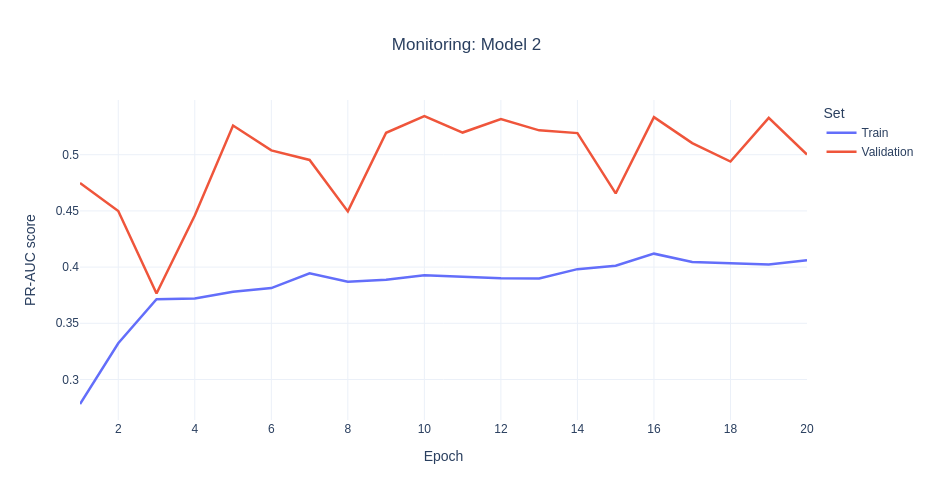

In [91]:
plot_monitoring(history_mlp_2, "Model MLP 2")

In [14]:
y_val_scores_mlp_2 = model_mlp_2.predict(X_val)
precisions_val_mlp_2, recalls_val_mlp_2, thresholds_val_mlp_2 = precision_recall_curve(y_val, y_val_scores_mlp_2)
calibrated_threshold_mlp_2 = thresholds_val_mlp_2[np.where(recalls_val_mlp_2 >= 0.80)[0][-1] ]

test_probs_mlp_2 = (model_mlp_2.predict(X_test)).ravel()
final_test_preds_mlp_2 = test_probs_mlp_2 > calibrated_threshold_mlp_2
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_mlp_2))

precision_mlp_2, recall_mlp_2, thresholds_mlp_2 = precision_recall_curve(y_test, test_probs_mlp_2)
pr_auc_mlp_2 = auc(recall_mlp_2, precision_mlp_2)
ap_mlp_2 = average_precision_score(y_test, test_probs_mlp_2)
print(f"PR-AUC Score: {pr_auc_mlp_2:.4f}")
print(f"Average Precision (AP) Score: {ap_mlp_2:.4f}")

14631/14631 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step
14631/14631 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step
-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    466815
           1       0.15      0.79      0.25      1377

    accuracy                           0.99    468192
   macro avg       0.58      0.89      0.62    468192
weighted avg       1.00      0.99      0.99    468192

PR-AUC Score: 0.4955
Average Precision (AP) Score: 0.4958


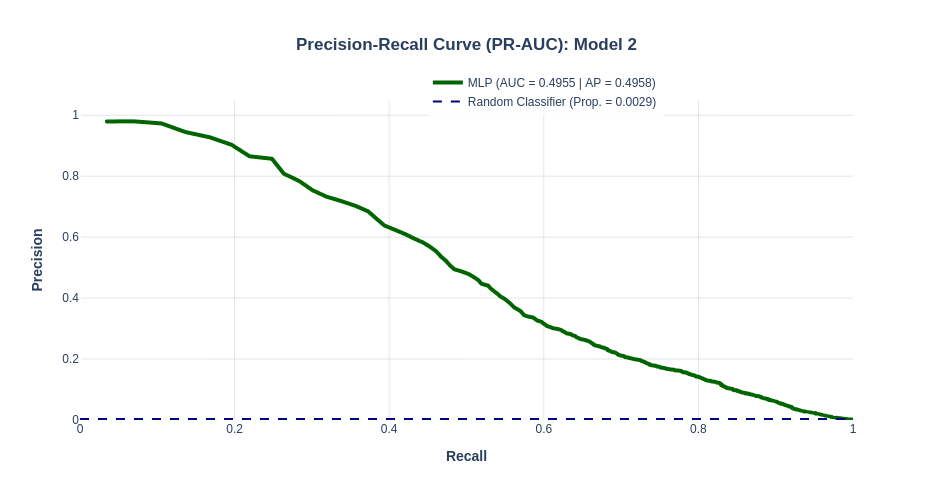

In [9]:
plot_PRAUC(precision_mlp_2, recall_mlp_2, pr_auc_mlp_2, ap_mlp_2, "MLP", "Model 2", "darkgreen")

En esta sección entrenaremos el modelo con una red convulocional

In [7]:
X_train_cnn = X_train[..., None]
X_val_cnn = X_val[..., None]    
X_test_cnn = X_test[..., None]

In [8]:
model_cnn_1 = tf.keras.Sequential([
    layers.Input(shape=(93, 1)), 
    
    layers.Conv1D(filters=64, kernel_size=5, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2), 
    layers.Dropout(0.2),
    
    layers.Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    
    layers.Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalMaxPooling1D(), 
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(1, activation='sigmoid')
])

model_cnn_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0,apply_class_balancing=True, alpha=0.997 ),
    metrics=[
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

checkpoint_3 = create_checkpoint(f"{path}mldl/DL_CNN_1.keras")

history_cnn_1 = model_cnn_1.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=2048, 
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stopping, checkpoint_3]
)

/home/diego/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1786360021.625257   30730 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - loss: 0.0015 - pr_auc: 0.0132 - precision: 0.0089 - recall: 0.7384
Epoch 1: val_pr_auc improved from None to 0.15004, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_1.keras

Epoch 1: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_1.keras
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 616s 575ms/step - loss: 0.0011 - pr_auc: 0.0211 - precision: 0.0130 - recall: 0.7971 - val_loss: 4.2165e-04 - val_pr_auc: 0.1500 - val_precision: 0.0492 - val_recall: 0.8765
Epoch 2/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - loss: 6.6047e-04 - pr_auc: 0.0507 - precision: 0.0259 - recall: 0.8542
Epoch 2: val_pr_auc improved from 0.15004 to 0.17151, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_1.keras

Epoch 2: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_1.keras
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 615s 576ms/step - loss: 6.0922e-04 - pr_auc: 0.0584 - p

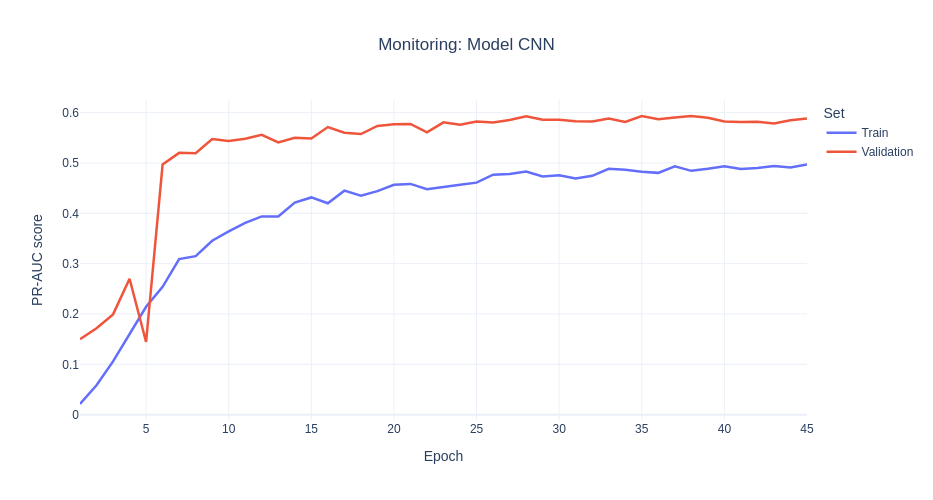

In [11]:
plot_monitoring(history_cnn?1, "Model CNN 1")

In [18]:
y_val_scores_cnn_1 = model_cnn_1.predict(X_val)
precisions_val_cnn_1, recalls_val_cnn_1, thresholds_val_cnn_1 = precision_recall_curve(y_val, y_val_scores_cnn_1)
calibrated_threshold_cnn_1 = thresholds_val_cnn_1[np.where(recalls_val_cnn_1 >= 0.80)[0][-1]]

test_probs_cnn_1 = (model_cnn_1.predict(X_test)).ravel()
final_test_preds_cnn_1 = test_probs_cnn_1 > calibrated_threshold_cnn_1
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_cnn_1))

precision_cnn_1, recall_cnn_1, thresholds_cnn_1 = precision_recall_curve(y_test, test_probs_cnn_1)
pr_auc_cnn_1 = auc(recall_cnn_1, precision_cnn_1)
ap_cnn_1 = average_precision_score(y_test, test_probs_cnn_1)
print(f"PR-AUC Score: {pr_auc_cnn_1:.4f}")
print(f"Average Precision (AP) Score: {ap_cnn_1:.4f}")

14631/14631 ━━━━━━━━━━━━━━━━━━━━ 88s 6ms/step
14631/14631 ━━━━━━━━━━━━━━━━━━━━ 85s 6ms/step
-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    466815
           1       0.22      0.78      0.35      1377

    accuracy                           0.99    468192
   macro avg       0.61      0.89      0.67    468192
weighted avg       1.00      0.99      0.99    468192

PR-AUC Score: 0.5616
Average Precision (AP) Score: 0.5617


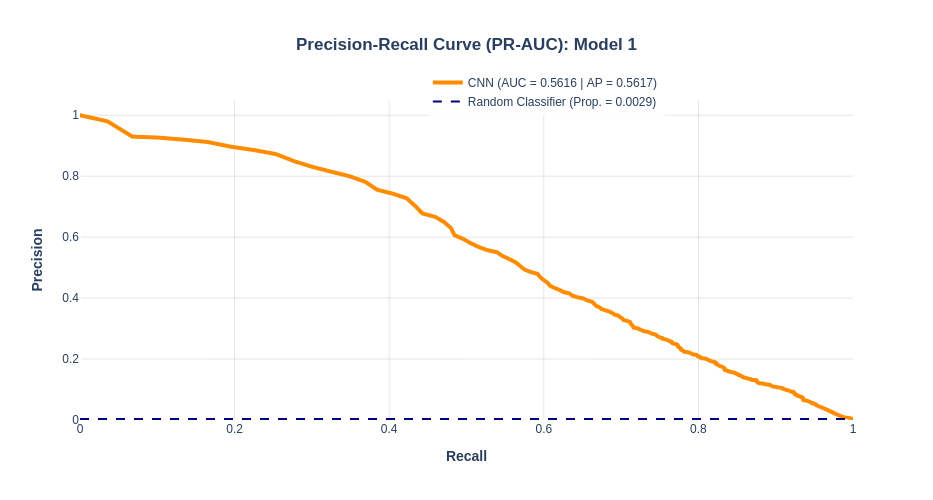

In [19]:
plot_PRAUC(precision_cnn_1, recall_cnn_1, pr_auc_cnn_1, ap_cnn_1, "CNN", "Model 1", "darkorange")

In [8]:
model_cnn_lstm_1 = tf.keras.Sequential([
    layers.Input(shape=(93, 1)), 
    
    layers.Conv1D(filters=64, kernel_size=5, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    
    layers.Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2), 
    layers.Dropout(0.2),
    
    layers.Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.LSTM(units=128, activation='tanh', recurrent_activation='sigmoid'), 
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'), 
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(1, activation='sigmoid')
])

model_cnn_lstm_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, apply_class_balancing=True, alpha=0.997),
    metrics=[
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

checkpoint_4 = create_checkpoint(f"{path}mldl/DL_CNN_LSTM_1.keras")

history_cnn_lstm_1 = model_cnn_lstm_1.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=2048, 
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stopping, checkpoint_4]
)

E0000 00:00:1786390323.957038   58813 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - loss: 0.0014 - pr_auc: 0.0087 - precision: 0.0063 - recall: 0.7105
Epoch 1: val_pr_auc improved from None to 0.30453, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_LSTM_1.keras

Epoch 1: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_LSTM_1.keras
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 917s 857ms/step - loss: 8.8480e-04 - pr_auc: 0.0175 - precision: 0.0098 - recall: 0.7979 - val_loss: 3.7878e-04 - val_pr_auc: 0.3045 - val_precision: 0.0723 - val_recall: 0.8699
Epoch 2/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - loss: 4.4969e-04 - pr_auc: 0.1319 - precision: 0.0303 - recall: 0.8848
Epoch 2: val_pr_auc improved from 0.30453 to 0.43031, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_LSTM_1.keras

Epoch 2: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_LSTM_1.keras
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 910s 853ms/step - loss: 4.1663e

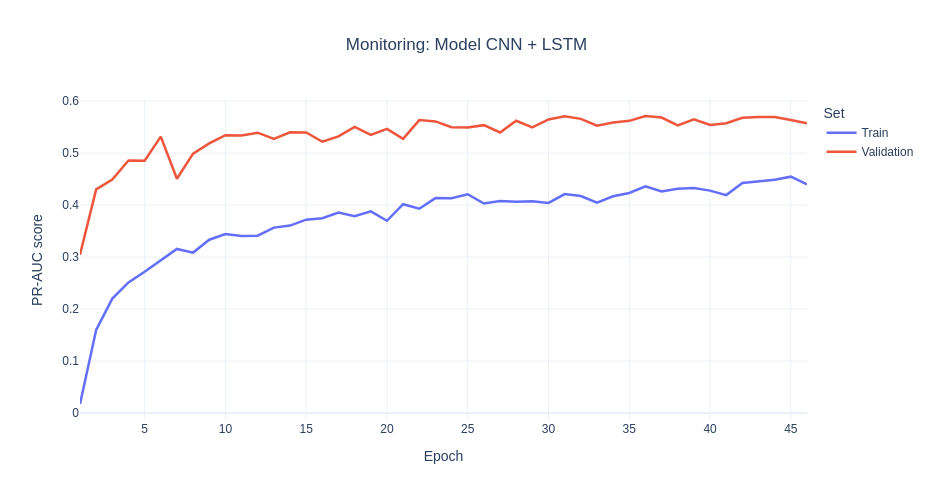

In [12]:
plot_monitoring(history_cnn_lstm, "Model CNN + LSTM 1")

In [9]:
y_val_scores_cnn_lstm_1 = model_cnn_lstm_1.predict(X_val)
precisions_val_cnn_lstm_1, recalls_val_cnn_lstm_1, thresholds_val_cnn_lstm_1 = precision_recall_curve(y_val, y_val_scores_cnn_lstm_1)
calibrated_threshold_cnn_lstm_1 = thresholds_val_cnn_lstm_1[np.where(recalls_val_cnn_lstm_1 >= 0.80)[0][-1]]

test_probs_cnn_lstm_1 = (model_cnn_lstm_1.predict(X_test)).ravel()
final_test_preds_cnn_lstm_1 = test_probs_cnn_lstm_1 > calibrated_threshold_cnn_lstm_1
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_cnn_lstm_1))

precision_cnn_lstm_1, recall_cnn_lstm_1, thresholds_cnn_lstm_1 = precision_recall_curve(y_test, test_probs_cnn_lstm_1)
pr_auc_cnn_lstm_1 = auc(recall_cnn_lstm_1, precision_cnn_lstm_1)
ap_cnn_lstm_1 = average_precision_score(y_test, test_probs_cnn_lstm_1)
print(f"PR-AUC Score: {pr_auc_cnn_lstm_1:.4f}")
print(f"Average Precision (AP) Score: {ap_cnn_lstm_1:.4f}")

14631/14631 ━━━━━━━━━━━━━━━━━━━━ 247s 17ms/step
14631/14631 ━━━━━━━━━━━━━━━━━━━━ 245s 17ms/step
-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    466815
           1       0.23      0.78      0.35      1377

    accuracy                           0.99    468192
   macro avg       0.61      0.88      0.67    468192
weighted avg       1.00      0.99      0.99    468192

PR-AUC Score: 0.5517
Average Precision (AP) Score: 0.5518


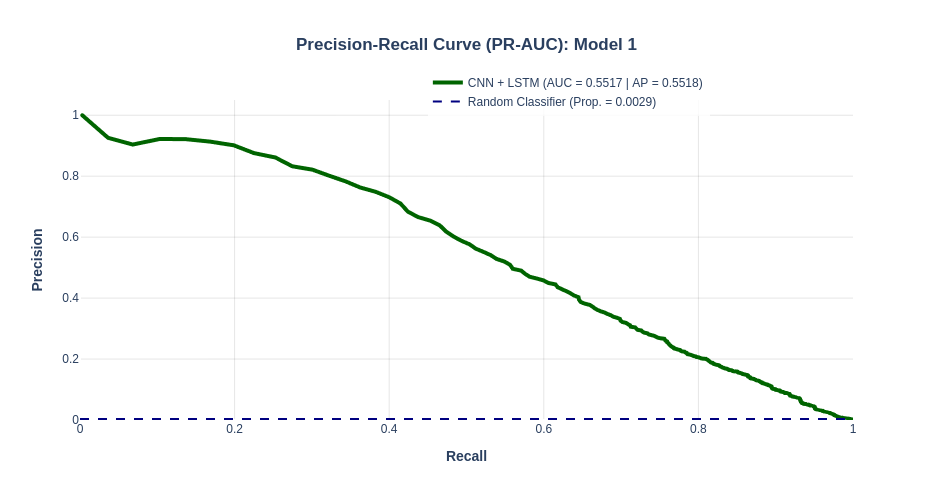

In [11]:
plot_PRAUC(precision_cnn_lstm_1, recall_cnn_lstm_1, pr_auc_cnn_lstm_1, ap_cnn_lstm_1, "CNN + LSTM", "Model 1", "darkgreen")

A continuación separaremos nuestros datos de entrenamiento, validación y test por orden temporal. Y crearemos ventanas temporales de 5 secuencias para el entrenamiento de la red convulocional.

In [9]:
import sys
import gc

for var in list(globals().keys()):
    if not var.startswith('_') and var not in ['sys', 'gc', 'path']:
        tipo_var = str(type(globals()[var]))
        if 'function' not in tipo_var and 'module' not in tipo_var and 'type' not in tipo_var:
            del globals()[var]

gc.collect()

df = (
    pl.scan_parquet(f"{path}data/gold/Polars/feature_complete_fraud_data.parquet")
    .select(pl.all().exclude("merchant_latitude", "merchant_longitude"))
    .collect()
)

In [10]:
WINDOW_SIZE = 5

df = df.sort("date")
total_rows = len(df)
train_index = int(total_rows * 0.70)
val_index = int(total_rows * 0.85)

VAL_CUTOFF_DATE = df["date"][train_index]
TEST_CUTOFF_DATE = df["date"][val_index]

train_df = (
    df.filter(pl.col("date") < VAL_CUTOFF_DATE)
    .sort(["client_id", "card_id", "date", "id"])
)
val_df = (
    df.filter((pl.col("date") >= VAL_CUTOFF_DATE) & (pl.col("date") < TEST_CUTOFF_DATE))
    .sort(["client_id", "card_id", "date", "id"])
)
test_df = (
    df.filter(pl.col("date") >= TEST_CUTOFF_DATE)
    .sort(["client_id", "card_id", "date", "id"])
)

excluded_columns = ["id", "client_id", "card_id", "date", "target", "window_target"]
columns_to_scale = train_df.select(pl.all().exclude(excluded_columns)).columns
scaler = StandardScaler()
scaler.fit(train_df.select(columns_to_scale).to_pandas())

def apply_scaling(df_polars, data_scaler, columns):
    transformed_df = pl.DataFrame(
        data_scaler.transform(df_polars.select(columns).to_pandas()), 
        schema=columns
    )
    return df_polars.with_columns([transformed_df[c] for c in columns])

def build_windows_by_id_join(df, window_size, is_train=True):            
    flat_ids_df = (
        df.select(["client_id", "card_id", "date", "id", "target"])
        .with_columns([
            *[pl.col("id").shift(window_size - 1 - i).over(["client_id", "card_id"]).alias(f"id_step_{i}") 
              for i in range(window_size)],
            pl.any_horizontal([
                pl.col("target").shift(i).over(["client_id", "card_id"]) 
                for i in range(window_size)
            ]).alias("window_target")
        ])
        .drop_nulls(subset=["id_step_0", "window_target"])
    )

    id_cols = [f"id_step_{i}" for i in range(window_size)]
    window_targets = flat_ids_df["window_target"].to_numpy().astype(np.int32)
    flat_ids_df = flat_ids_df.select(id_cols)

    feature_cols = df.select(pl.all().exclude(["client_id", "card_id", "date", "id", "target"])).columns
    raw_ids = df["id"].to_numpy()
    raw_features = df.select(feature_cols).to_numpy().astype(np.float32)
    del df
    gc.collect()
    
    id_to_index = {id_val: idx for idx, id_val in enumerate(raw_ids)}
    num_samples = len(flat_ids_df)
    num_features = len(feature_cols)
    X_3d = np.empty((num_samples, window_size, num_features), dtype=np.float32)
    
    for step in range(window_size):
        step_ids = flat_ids_df[f"id_step_{step}"].to_numpy()
        feature_indices = [id_to_index[id_val] for id_val in step_ids]
        X_3d[:, step, :] = raw_features[feature_indices]
        
    del raw_features, raw_ids, id_to_index, flat_ids_df
    gc.collect()
    
    return X_3d, window_targets


In [11]:
train_df = apply_scaling(train_df, scaler, columns_to_scale)
X_train, y_train = build_windows_by_id_join(train_df, WINDOW_SIZE, is_train=True)
del train_df
gc.collect()
np.save(f"{path}data/silver/Polars/X_train_w5.npy", X_train)
np.save(f"{path}data/silver/Polars/y_train_w5.npy", y_train)

In [12]:
val_df = apply_scaling(val_df, scaler, columns_to_scale)
X_val, y_val = build_windows_by_id_join(val_df, WINDOW_SIZE, is_train=False)
del val_df
gc.collect()
np.save(f"{path}data/silver/Polars/X_val_w5.npy", X_val)
np.save(f"{path}data/silver/Polars/y_val_w5.npy", y_val)

In [13]:
test_df = apply_scaling(test_df, scaler, columns_to_scale)
X_test, y_test = build_windows_by_id_join(test_df, WINDOW_SIZE, is_train=False)
del test_df
gc.collect()
np.save(f"{path}data/silver/Polars/X_test_w5.npy", X_test)
np.save(f"{path}data/silver/Polars/y_test_w5.npy", y_test)

In [15]:
model_cnn_2 = models.Sequential([
    layers.Input(shape=(X_train.shape[1], X_train.shape[2])), 
    
    layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=1), 
    layers.Dropout(0.2),
    
    layers.Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=1),
    layers.Dropout(0.2),
    
    layers.Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalMaxPooling1D(), 
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(1, activation='sigmoid')
])

model_cnn_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0,apply_class_balancing=True, alpha=0.997 ),
    metrics=[
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

checkpoint_5 = create_checkpoint(f"{path}mldl/DL_CNN_2.keras")

history_cnn_2 = model_cnn_2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=2048, 
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint_5]
)

E0000 00:00:1786712722.745143   31080 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0016 - pr_auc: 0.0703 - precision: 0.0165 - recall: 0.8571
Epoch 1: val_pr_auc improved from None to 0.22416, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_2.keras

Epoch 1: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_2.keras
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 145s 134ms/step - loss: 0.0010 - pr_auc: 0.1221 - precision: 0.0224 - recall: 0.8883 - val_loss: 0.0015 - val_pr_auc: 0.2242 - val_precision: 0.0899 - val_recall: 0.7191
Epoch 2/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 5.6216e-04 - pr_auc: 0.3249 - precision: 0.0421 - recall: 0.9328
Epoch 2: val_pr_auc improved from 0.22416 to 0.26328, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_2.keras

Epoch 2: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_2.keras
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 145s 136ms/step - loss: 5.2117e-04 - pr_auc: 0.3617 - preci

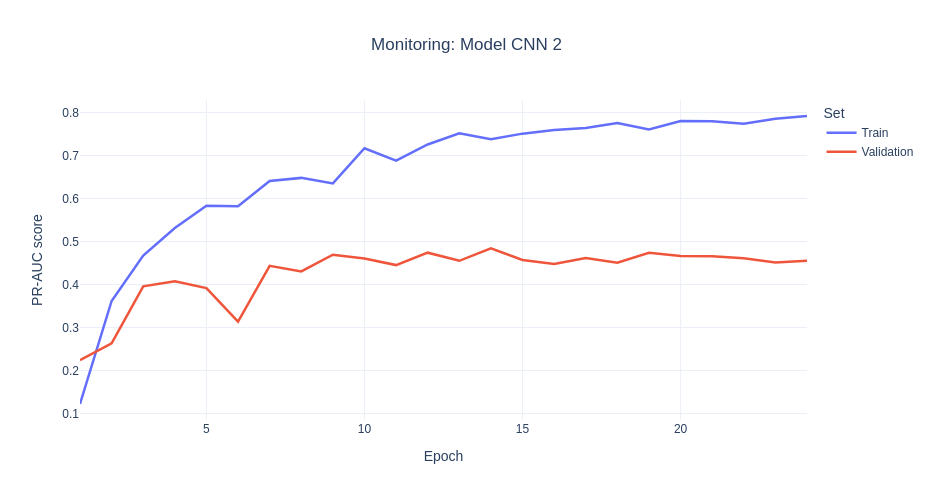

In [19]:
plot_monitoring(history_cnn_2, "Model CNN 2")

In [23]:
y_val_scores_cnn_2 = model_cnn_2.predict(X_val)
precisions_val_cnn_2, recalls_val_cnn_2, thresholds_val_cnn_2 = precision_recall_curve(y_val, y_val_scores_cnn_2)
calibrated_threshold_cnn_2 = thresholds_val_cnn_2[np.where(recalls_val_cnn_2 >= 0.80)[0][-1]]

test_probs_cnn_2 = (model_cnn_2.predict(X_test)).ravel()
final_test_preds_cnn_2 = test_probs_cnn_2 > calibrated_threshold_cnn_2
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_cnn_2))

precision_cnn_2, recall_cnn_2, thresholds_cnn_2 = precision_recall_curve(y_test, test_probs_cnn_2)
pr_auc_cnn_2 = auc(recall_cnn_2, precision_cnn_2)
ap_cnn_2 = average_precision_score(y_test, test_probs_cnn_2)
print(f"PR-AUC Score: {pr_auc_cnn_2:.4f}")
print(f"Average Precision (AP) Score: {ap_cnn_2:.4f}")

14200/14200 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step
14199/14199 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step
-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    451071
           1       0.08      0.80      0.15      3295

    accuracy                           0.93    454366
   macro avg       0.54      0.87      0.56    454366
weighted avg       0.99      0.93      0.96    454366

PR-AUC Score: 0.4311
Average Precision (AP) Score: 0.4312


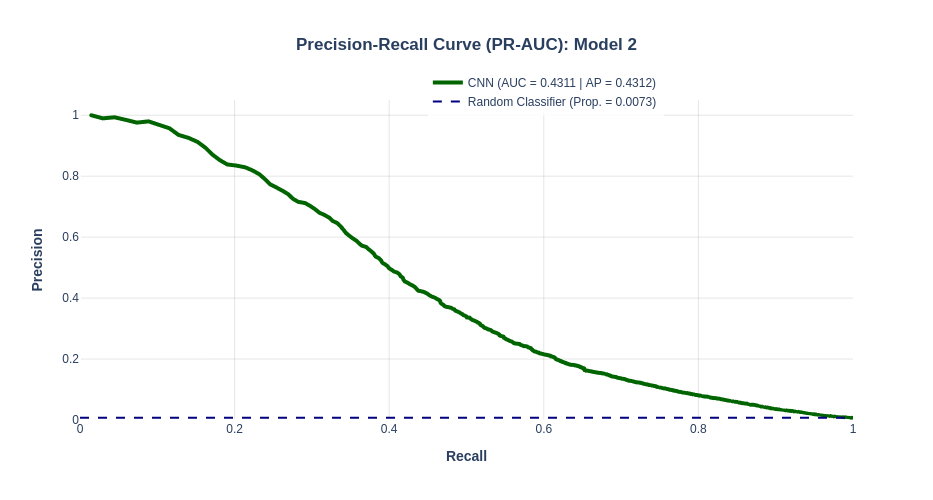

In [24]:
plot_PRAUC(precision_cnn_2, recall_cnn_2, pr_auc_cnn_2, ap_cnn_2, "CNN", "Model 2", "darkgreen")

In [2]:
for var in list(globals().keys()):
    if not var.startswith('_') and var not in ['sys', 'gc', 'path']:
        tipo_var = str(type(globals()[var]))
        if 'function' not in tipo_var and 'module' not in tipo_var and 'type' not in tipo_var:
            del globals()[var]

gc.collect()

X_train = np.load(f"{path}data/silver/Polars/X_train_w5.npy")
y_train = np.load(f"{path}data/silver/Polars/y_train_w5.npy")

X_val = np.load(f"{path}data/silver/Polars/X_val_w5.npy")
y_val = np.load(f"{path}data/silver/Polars/y_val_w5.npy")

X_test = np.load(f"{path}data/silver/Polars/X_test_w5.npy")
y_test = np.load(f"{path}data/silver/Polars/y_test_w5.npy")

In [12]:
model_cnn_lstm_2 = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1], X_train.shape[2])),

    layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=1),
    layers.Dropout(0.2),

    layers.Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=1),
    layers.Dropout(0.2),

    layers.Conv1D(filters=256, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.LSTM(units=128, activation='tanh', recurrent_activation='sigmoid'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

model_cnn_lstm_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, apply_class_balancing=True, alpha=0.997),
    metrics=[
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

checkpoint_6 = create_checkpoint(f"{path}mldl/DL_CNN_LSTM_2.keras")

history_cnn_lstm_2 = model_cnn_lstm_2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=2048,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint_6]
)

Epoch 1/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 0.0014 - pr_auc: 0.0685 - precision: 0.0157 - recall: 0.8634
Epoch 1: val_pr_auc improved from None to 0.32290, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_LSTM_2.keras

Epoch 1: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_LSTM_2.keras
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 240s 222ms/step - loss: 8.9886e-04 - pr_auc: 0.1140 - precision: 0.0213 - recall: 0.8958 - val_loss: 0.0013 - val_pr_auc: 0.3229 - val_precision: 0.0696 - val_recall: 0.7724
Epoch 2/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - loss: 4.8128e-04 - pr_auc: 0.4845 - precision: 0.0431 - recall: 0.9395
Epoch 2: val_pr_auc improved from 0.32290 to 0.38608, saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_LSTM_2.keras

Epoch 2: finished saving model to /home/diego/BigData/financial-fraud-MLOps/mldl/DL_CNN_LSTM_2.keras
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 235s 222ms/step - loss: 4.5785e-04 

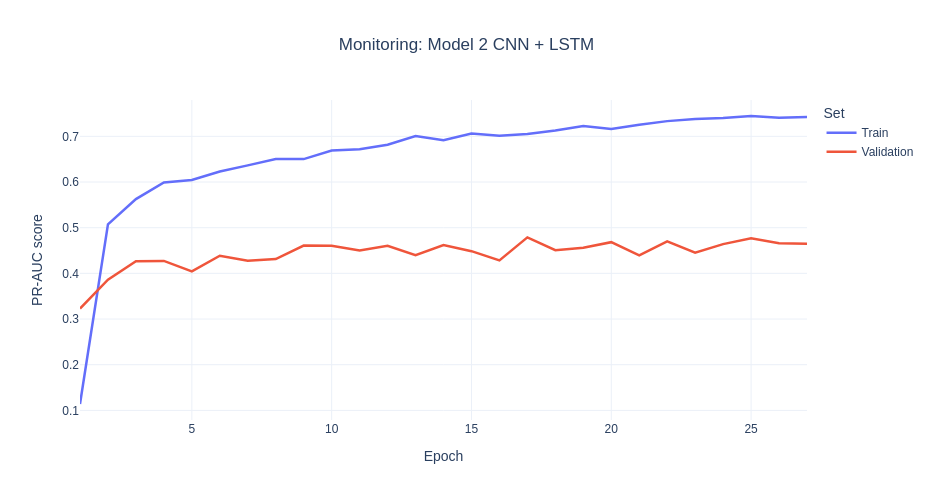

In [17]:
plot_monitoring(history_cnn_lstm_2, "Model CNN + LSTM 2")

In [18]:
y_val_scores_cnn_lstm_2 = model_cnn_lstm_2.predict(X_val)
precisions_val_cnn_lstm_2, recalls_val_cnn_lstm_2, thresholds_val_cnn_lstm_2 = precision_recall_curve(y_val, y_val_scores_cnn_lstm_2)
calibrated_threshold_cnn_lstm_2 = thresholds_val_cnn_lstm_2[np.where(recalls_val_cnn_lstm_2 >= 0.80)[0][-1]]

test_probs_cnn_lstm_2 = (model_cnn_lstm_2.predict(X_test)).ravel()
final_test_preds_cnn_lstm_2 = test_probs_cnn_lstm_2 > calibrated_threshold_cnn_lstm_2
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_cnn_lstm_2))

precision_cnn_lstm_2, recall_cnn_lstm_2, thresholds_cnn_lstm_2 = precision_recall_curve(y_test, test_probs_cnn_lstm_2)
pr_auc_cnn_lstm_2 = auc(recall_cnn_lstm_2, precision_cnn_lstm_2)
ap_cnn_lstm_2 = average_precision_score(y_test, test_probs_cnn_lstm_2)
print(f"PR-AUC Score: {pr_auc_cnn_lstm_2:.4f}")
print(f"Average Precision (AP) Score: {ap_cnn_lstm_2:.4f}")

14200/14200 ━━━━━━━━━━━━━━━━━━━━ 90s 6ms/step
14199/14199 ━━━━━━━━━━━━━━━━━━━━ 90s 6ms/step
-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    451071
           1       0.08      0.81      0.14      3295

    accuracy                           0.93    454366
   macro avg       0.54      0.87      0.55    454366
weighted avg       0.99      0.93      0.96    454366

PR-AUC Score: 0.4327
Average Precision (AP) Score: 0.4328


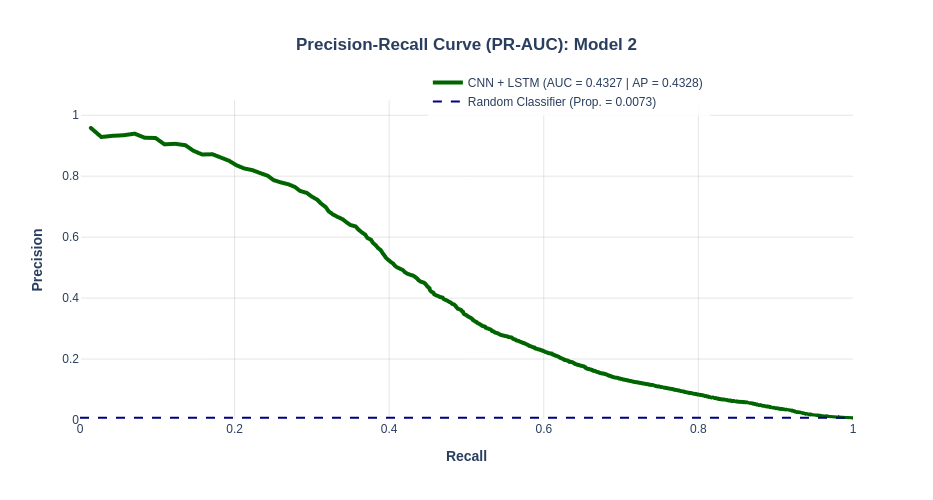

In [20]:
plot_PRAUC(precision_cnn_lstm_2, recall_cnn_lstm_2, pr_auc_cnn_lstm_2, ap_cnn_lstm_2, "CNN + LSTM", "Model 2", "darkgreen")